In [3]:
!pip install tensorflow


  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached absl_py-2.2.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.4-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached wrapt-1.17.2-cp312-cp312-win_amd64.whl.metadata (6.5 kB)
  Using cached grpcio-1.71.0-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.1-py3-none-any.whl.metadata (6.1 kB)
  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached h5py-3.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [12]:
labels = {
    0 : "T-shirt/top", 
    1: "Trouser", 
    2: "Pullover", 
    3: "Dress", 
    4: "Coat",
    5: "Sandal", 
    6: "Shirt", 
    7: "Sneaker", 
    8: "Bag", 
    9: "Ankle Boot"
}

In [34]:
def split_csv():
    try:
        train_path_1 = os.path.join('..', 'data', 'fashon-mnist_train.csv')
        training_df = pd.read_csv(train_path_1)

        mid_point = len(training_df) // 2
        
        # Split the DataFrame
        df_1 = training_df.iloc[:mid_point]
        df_2 = training_df.iloc[mid_point:]
        file_1 = os.path.join('..', 'data', 'fashon-mnist_training_1.csv')
        file_2 = os.path.join('..', 'data', 'fashon-mnist_training_2.csv')
        # Save the two DataFrames into separate CSVs
        df_1.to_csv(file_1, index=False)
        df_2.to_csv(file_2, index=False)
        print("Data successfully split into two files: 'fashon-mnist_train_1.csv' and 'fashon-mnist_train_2.csv'")
    except Exception as e:
        print("If you see fashon-mnist_training_1.csv and fashon-mnist_training_2.csv in the data folder then please ignore this error. \n", e)

split_csv()

Data successfully split into two files: 'fashon-mnist_train_1.csv' and 'fashon-mnist_train_2.csv'


In [36]:
def load_data():
    """
    Load the training and testing CSV files.
    """

    train_path_1 = os.path.join('..', 'data', 'fashon-mnist_training_1.csv')
    train_path_2 = os.path.join('..', 'data', 'fashon-mnist_training_2.csv')
    test_path = os.path.join('..', 'data', 'fashon-mnist_test.csv')
    
    train_df_1 = pd.read_csv(train_path_1)
    train_df_2 = pd.read_csv(train_path_2)
    test_df = pd.read_csv(test_path)

    combined_training_df = pd.concat([train_df_1, train_df_2], ignore_index=True)
    return combined_training_df, test_df


    # Load the data
training_df, test_df = load_data()

In [37]:
def explore_data_info(train_df, test_df):
    """Display basic information about the dataset."""
    print("\nFashion MNIST train -  rows:",train_df.shape[0]," columns:", train_df.shape[1])
    print("\nFashion MNIST test -  rows:",test_df.shape[0]," columns:", test_df.shape[1])
    print("\n--- Training Data Info ---\n")
    print(train_df.info())
    print("\n--- Testing Data Info ---\n")
    print(test_df.info())

explore_data_info(training_df, test_df)


Fashion MNIST train -  rows: 60000  columns: 785

Fashion MNIST test -  rows: 10000  columns: 785

--- Training Data Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
None

--- Testing Data Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB
None


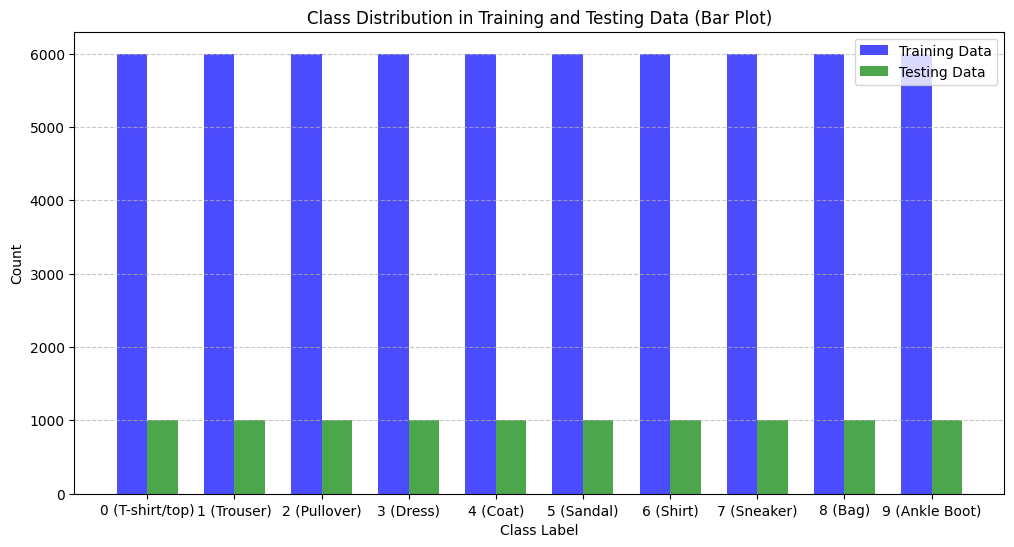

In [38]:
def plot_stacked_area(train_df, test_df):
    """
    Plot class distribution using a stacked area plot for visual comparison.
    """
    # Get class distribution
    train_counts = train_df.iloc[:, 0].value_counts().sort_index()
    test_counts = test_df.iloc[:, 0].value_counts().sort_index()

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame({
        'Class': train_counts.index,
        'Train Count': train_counts.values,
        'Test Count': test_counts.values
    })

    # Plot bar graph with side-by-side bars
    width = 0.35
    x = np.arange(len(plot_data['Class']))

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, plot_data['Train Count'], width=width, label='Training Data', color='blue', alpha=0.7)
    plt.bar(x + width/2, plot_data['Test Count'], width=width, label='Testing Data', color='green', alpha=0.7)

    plt.xlabel('Class Label')
    plt.ylabel('Count')
    plt.title('Class Distribution in Training and Testing Data (Bar Plot)')
    plt.xticks(x, [f'{cls} ({labels[cls]})' for cls in plot_data['Class']])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

plot_stacked_area(training_df, test_df)

In [39]:

def plot_one_image_per_class(df):
    """
    Plot one sample image from each class arranged from class 0 to 9 with text labels.
    """
    
    X = df.iloc[:, 1:].values
    y = df.iloc[:, 0].values

    # Find one image per class
    sample_images = []
    for label in range(10):
        index = np.where(y == label)[0][0]
        sample_images.append((X[index], label))

    plt.figure(figsize=(15, 7))
    for i, (image, label) in enumerate(sample_images):
        plt.subplot(2, 5, i + 1)
        plt.imshow(image.reshape(28, 28), cmap='gray')
        plt.title(f'{label}: {labels[label]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()



 Sample Image from Training Data Set 



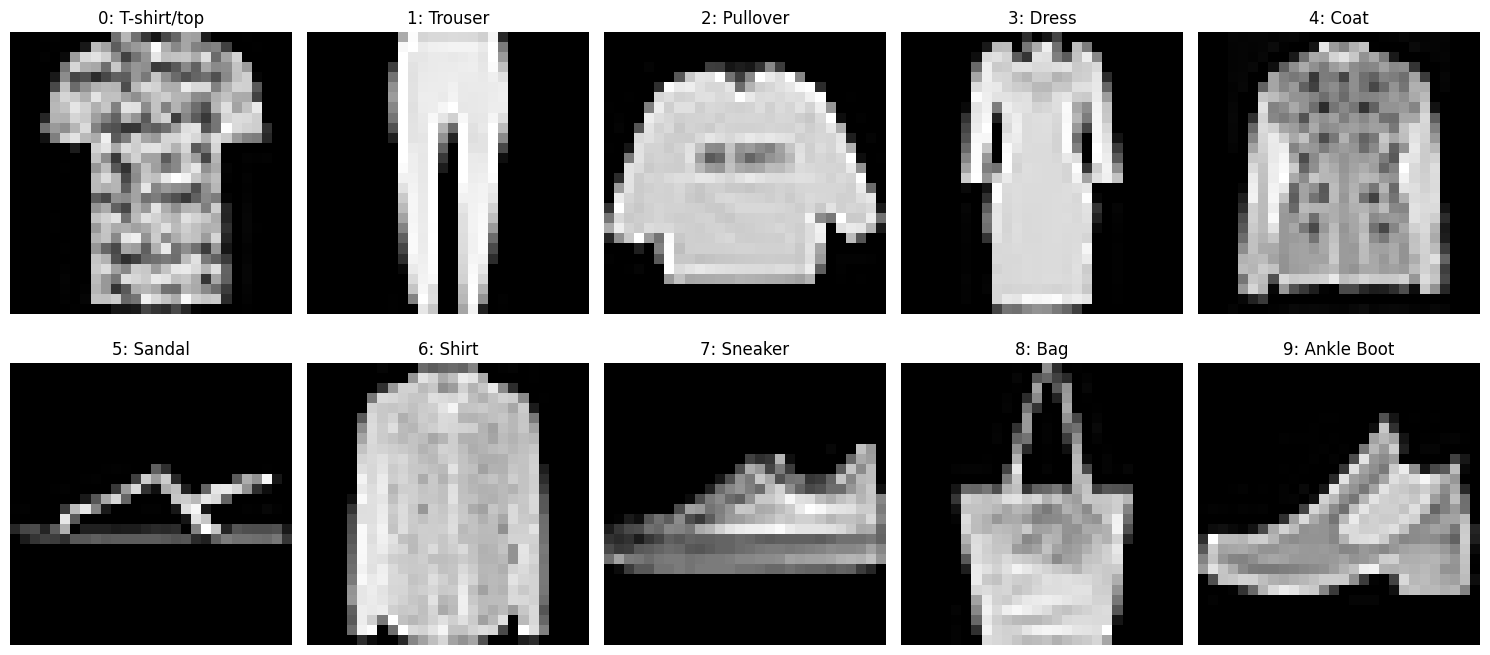

In [40]:
print("\n Sample Image from Training Data Set \n")
plot_one_image_per_class(training_df)



 Sample Image from Test Data Set 



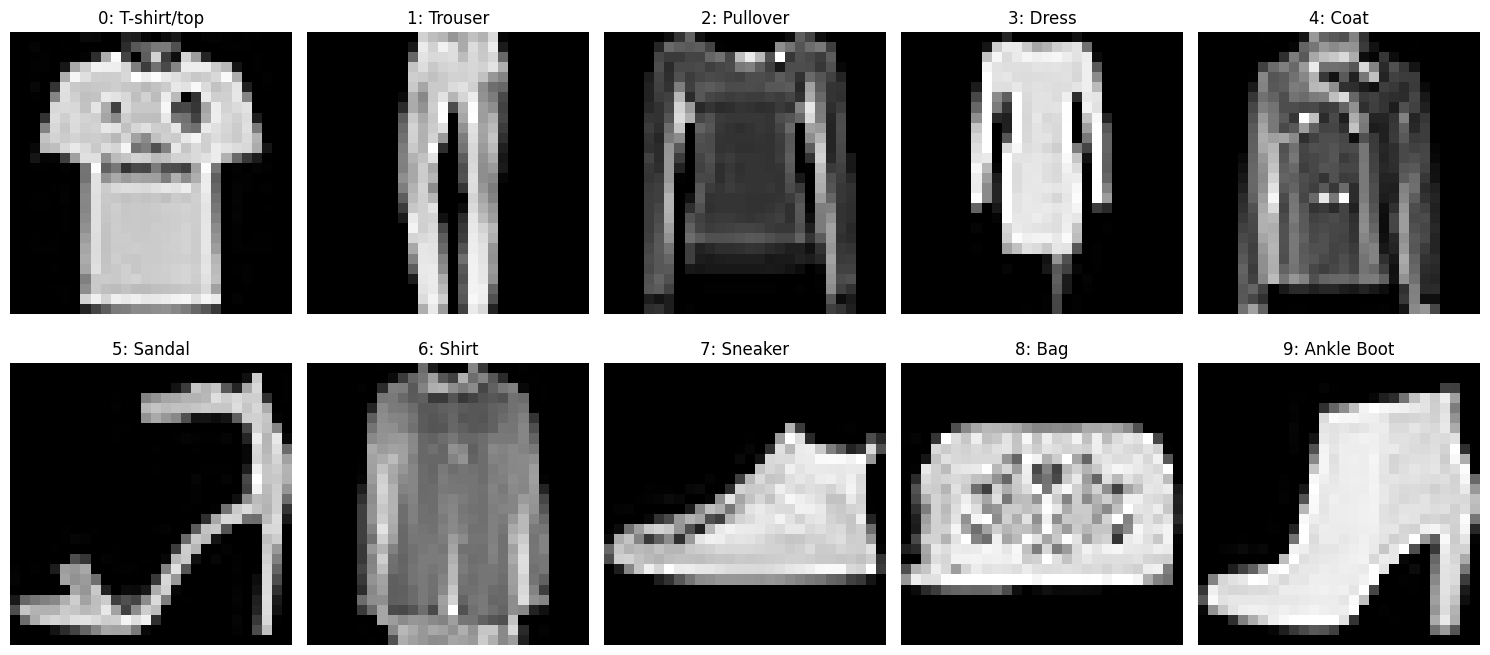

In [41]:
print("\n Sample Image from Test Data Set \n")
plot_one_image_per_class(test_df)

In [42]:

def preprocess_for_cnn(df):
    """
    Preprocess the dataframe for CNN training:
    - Normalize pixel values to [0, 1]
    - Reshape to (28, 28, 1)
    - Convert labels to one-hot encoded vectors
    """
    X = df.iloc[:, 1:].values.astype('float32') / 255.0  # Normalize pixel values
    X = X.reshape(-1, 28, 28, 1)                           # Reshape for CNN
    y = to_categorical(df.iloc[:, 0].values, num_classes=10)  # One-hot encode labels
    return X, y


def build_cnn_model():
    """
    Build and compile the CNN model.
    """
    model = Sequential([
        # First convolutional block
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Second convolutional block
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Fully connected layers
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def train_cnn_model(model, X_train, y_train, epochs=10, batch_size=128):
    """
    Train the CNN model on the training data.
    """
    history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
    return history

def evaluate_cnn_model(model, X_test, y_test):
    """
    Evaluate the trained CNN model on the test data and print the results.
    """
    score = model.evaluate(X_test, y_test, verbose=0)
    print('Test Loss:', score[0])
    print('Test Accuracy:', score[1])

def main():

    # Preprocess data for CNN training
    X_train_cnn, y_train_cnn = preprocess_for_cnn(training_df)
    X_test_cnn, y_test_cnn = preprocess_for_cnn(test_df)
    
    model = build_cnn_model()
    print("CNN Model Summary:")
    model.summary()
    
    print("\nTraining the CNN model...")
    history = train_cnn_model(model, X_train_cnn, y_train_cnn, epochs=10, batch_size=128)
    
    print("\nEvaluating the CNN model on test data:")
    evaluate_cnn_model(model, X_test_cnn, y_test_cnn)

if __name__ == '__main__':
    main()


CNN Model Summary:


c:\Users\atul1\Work\tools\Python3_12\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training the CNN model...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6078 - loss: 1.0669 - val_accuracy: 0.8193 - val_loss: 0.4839
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8085 - loss: 0.5232 - val_accuracy: 0.8603 - val_loss: 0.3938
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8314 - loss: 0.4576 - val_accuracy: 0.8673 - val_loss: 0.3681
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8504 - loss: 0.4092 - val_accuracy: 0.8847 - val_loss: 0.3267
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8665 - loss: 0.3702 - val_accuracy: 0.8882 - val_loss: 0.3113
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8674 - loss: 0.3661 - val_accuracy: 0.8900 - val_loss: 0.2954
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8742 - loss: 0.3477 - val_accuracy: 0.8997 - val_loss: 0.2810
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8794 - l